## Data

In [10]:
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import numpy as np

# %matplotlib notebook

<IPython.core.display.Javascript object>


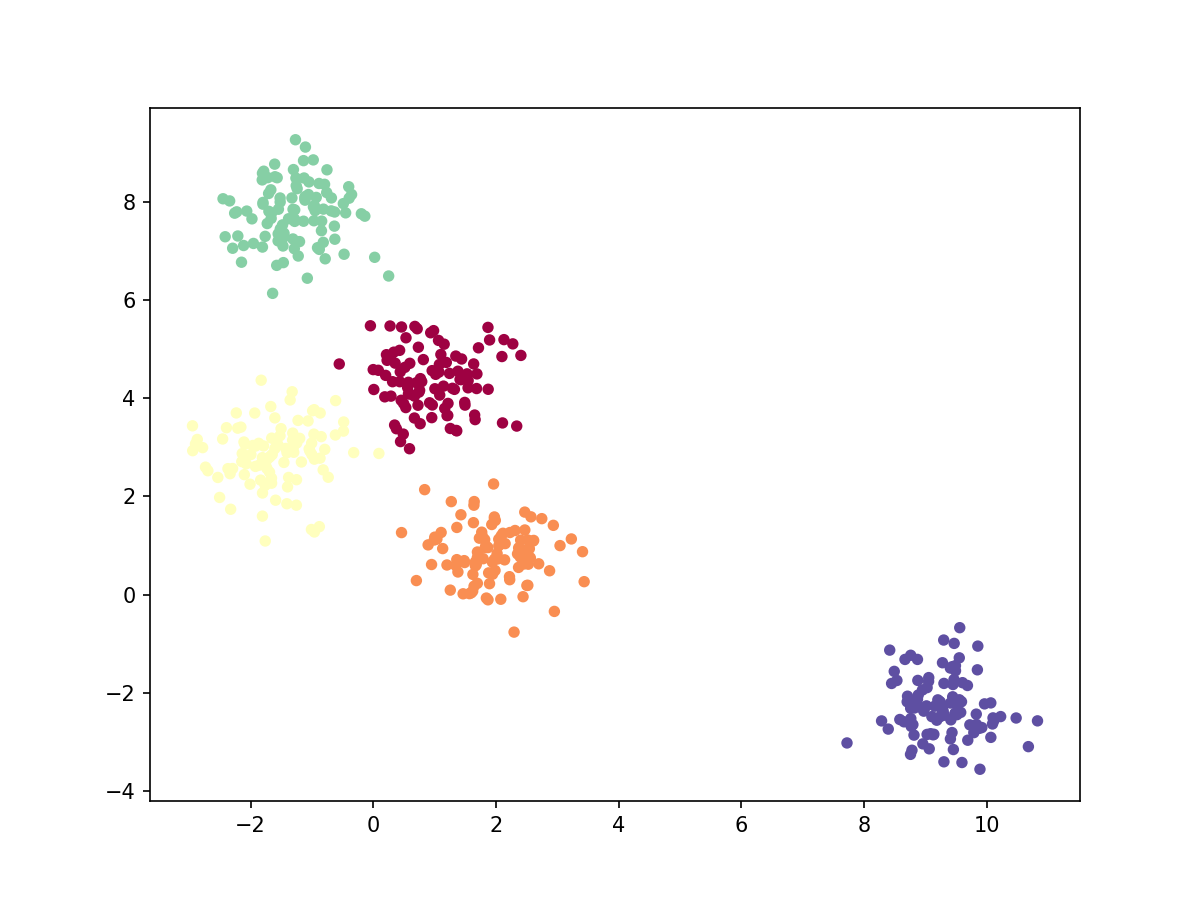

In [9]:
X, y = make_blobs(n_samples = 500, n_features = 2, centers = 5, 
                           cluster_std = 0.6, random_state = 0)
colors = np.array([plt.cm.Spectral(val)
          for val in np.linspace(0, 1, len(set(y)))])
plt.figure(figsize=(8,6))

plt.scatter(X[:,0], X[:,1], c= colors[y], s= 20)    

## Agglomerative clustering

### complete linkage

In [20]:
clf = AgglomerativeClustering(n_clusters=5, linkage= 'complete')
predicted = clf.fit_predict(X)

<IPython.core.display.Javascript object>


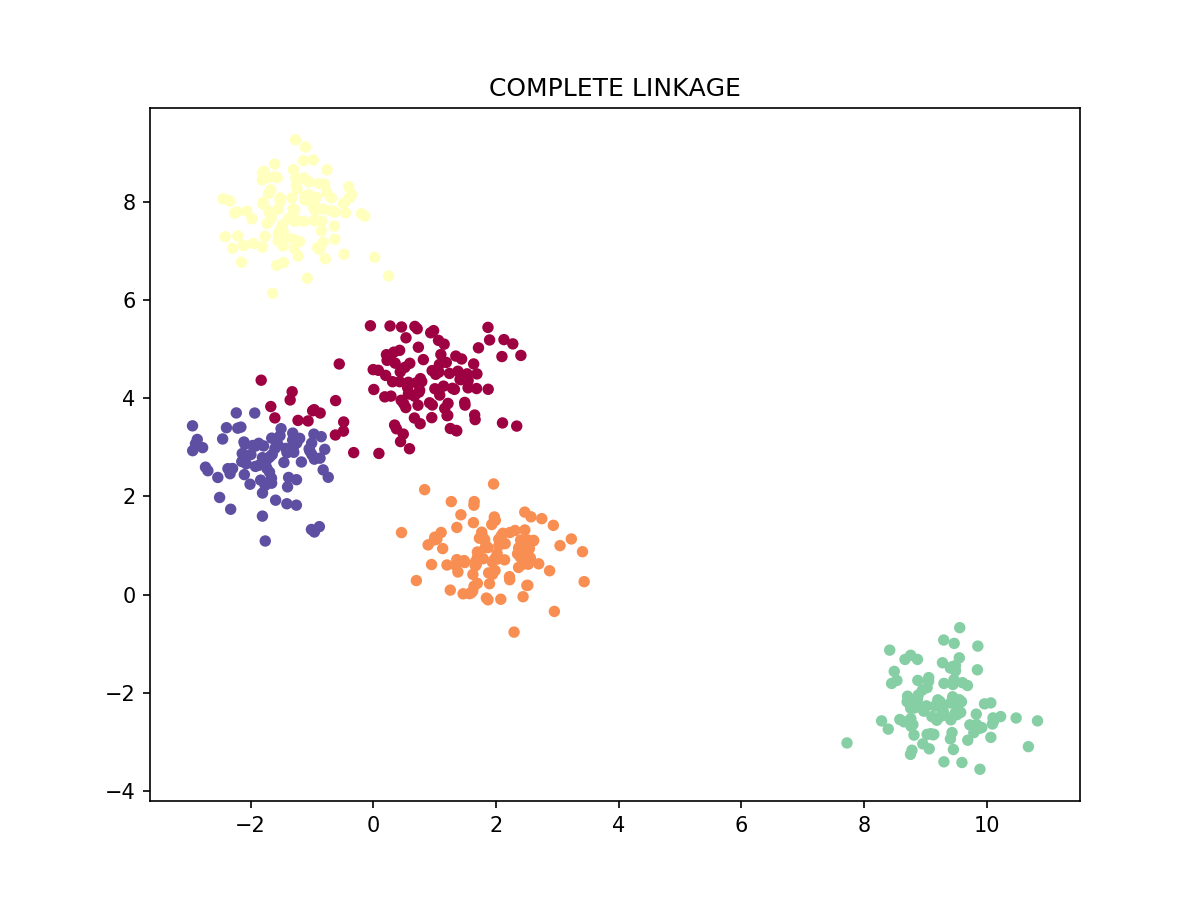

Text(0.5, 1.0, 'COMPLETE LINKAGE')

In [21]:
colors = np.array([plt.cm.Spectral(val)
          for val in np.linspace(0, 1, len(set(predicted)))])
plt.figure(figsize=(8,6))

plt.scatter(X[:,0], X[:,1], c= colors[predicted], s= 20)
plt.title ('COMPLETE LINKAGE')

### single linkage

In [22]:
clf = AgglomerativeClustering(n_clusters=5, linkage= 'single')
predicted = clf.fit_predict(X)

<IPython.core.display.Javascript object>


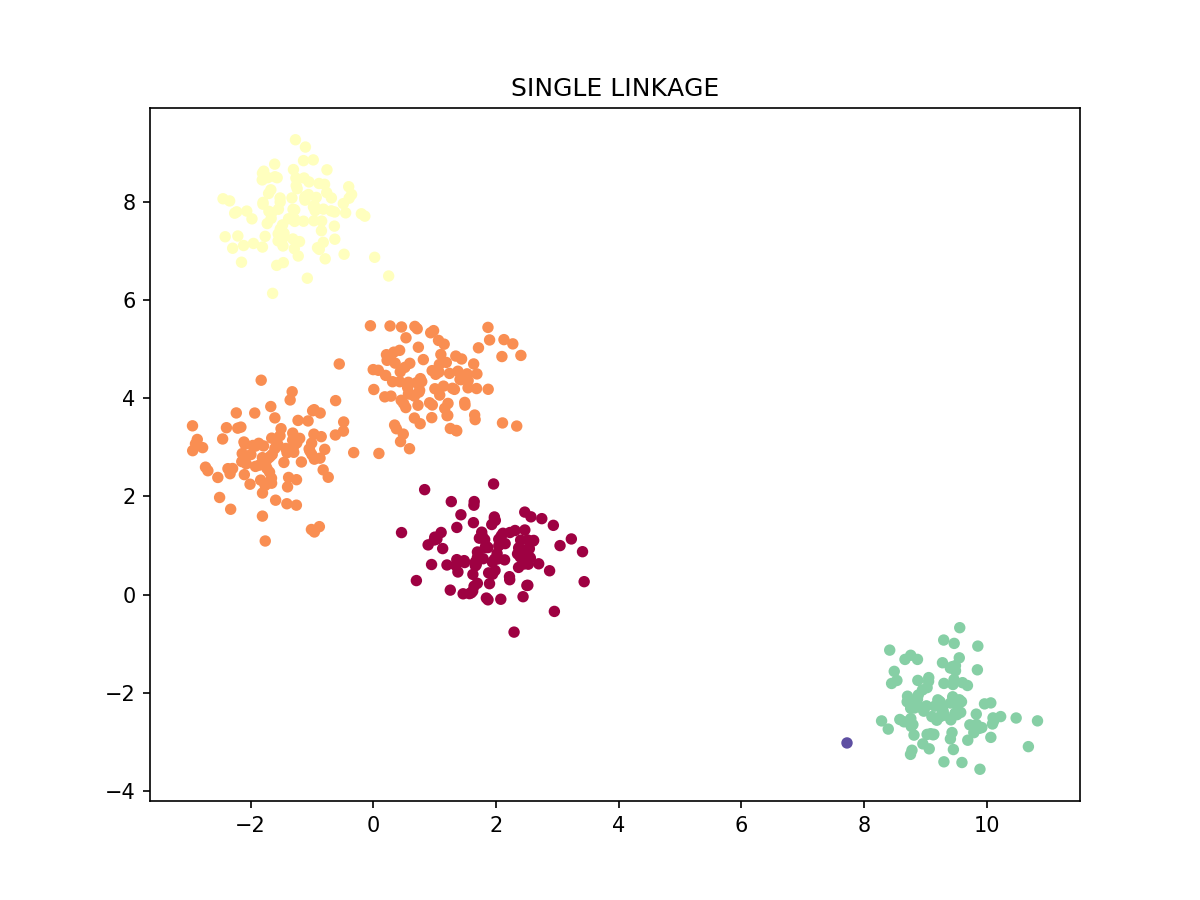

In [24]:
plt.figure(figsize=(8, 6))
colors = np.array([plt.cm.Spectral(val)
                   for val in np.linspace(0, 1, len(set(predicted)))])
plt.scatter(X[:, 0], X[:, 1], c=colors[predicted], s=20)
plt.title("SINGLE LINKAGE")
plt.show()

### DBSCAN

In [25]:
from sklearn.cluster import DBSCAN

In [32]:
db = DBSCAN(eps=0.75, min_samples=20).fit(X)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

<IPython.core.display.Javascript object>


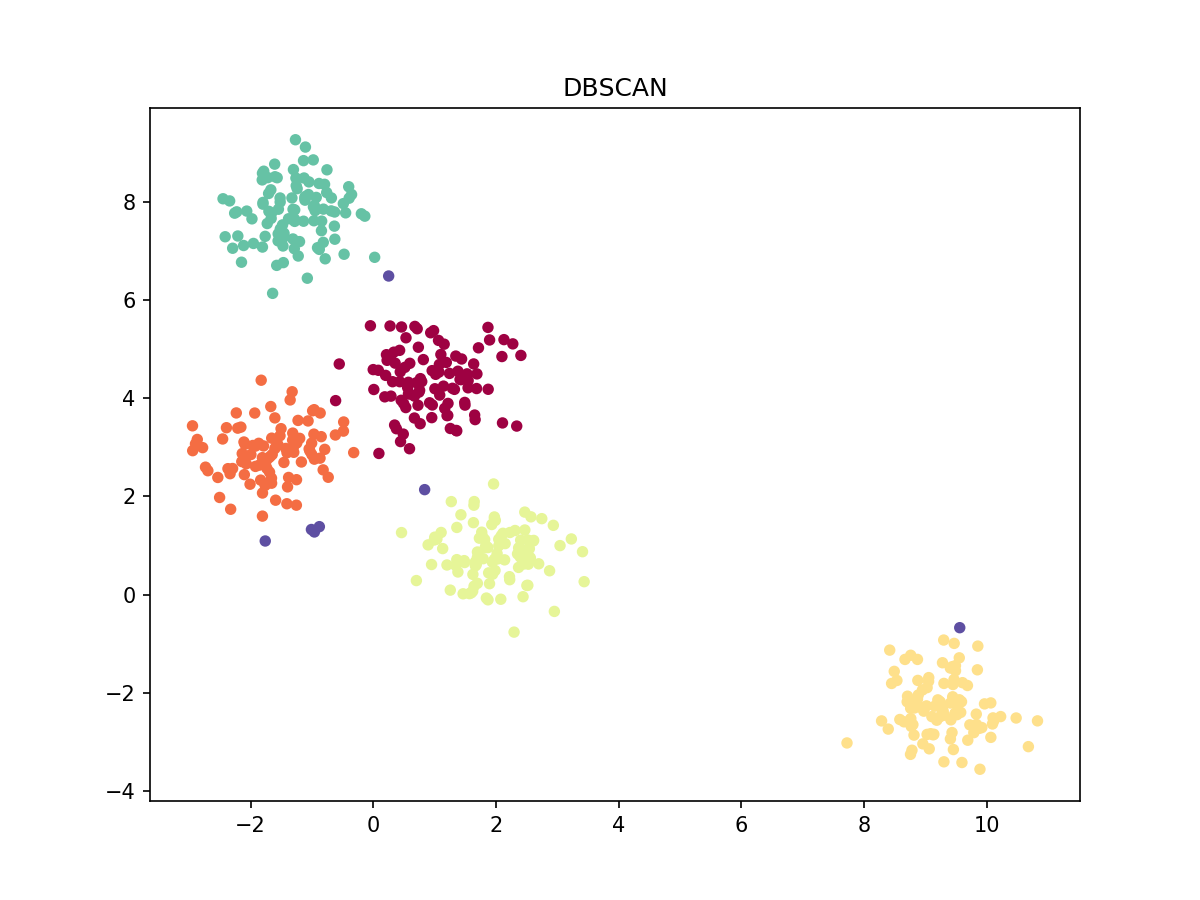

In [33]:
plt.figure(figsize=(8, 6))
colors = np.array([plt.cm.Spectral(val)
                   for val in np.linspace(0, 1, len(set(labels)))])
plt.scatter(X[:, 0], X[:, 1], c=colors[labels], s=20)
plt.title("DBSCAN")
plt.show()

## “elbow method” to determine the best k for K-Means

In [34]:
from sklearn.cluster import KMeans

In [35]:
inertia = []
k_range = range(1, 11)

In [36]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=0)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

<IPython.core.display.Javascript object>


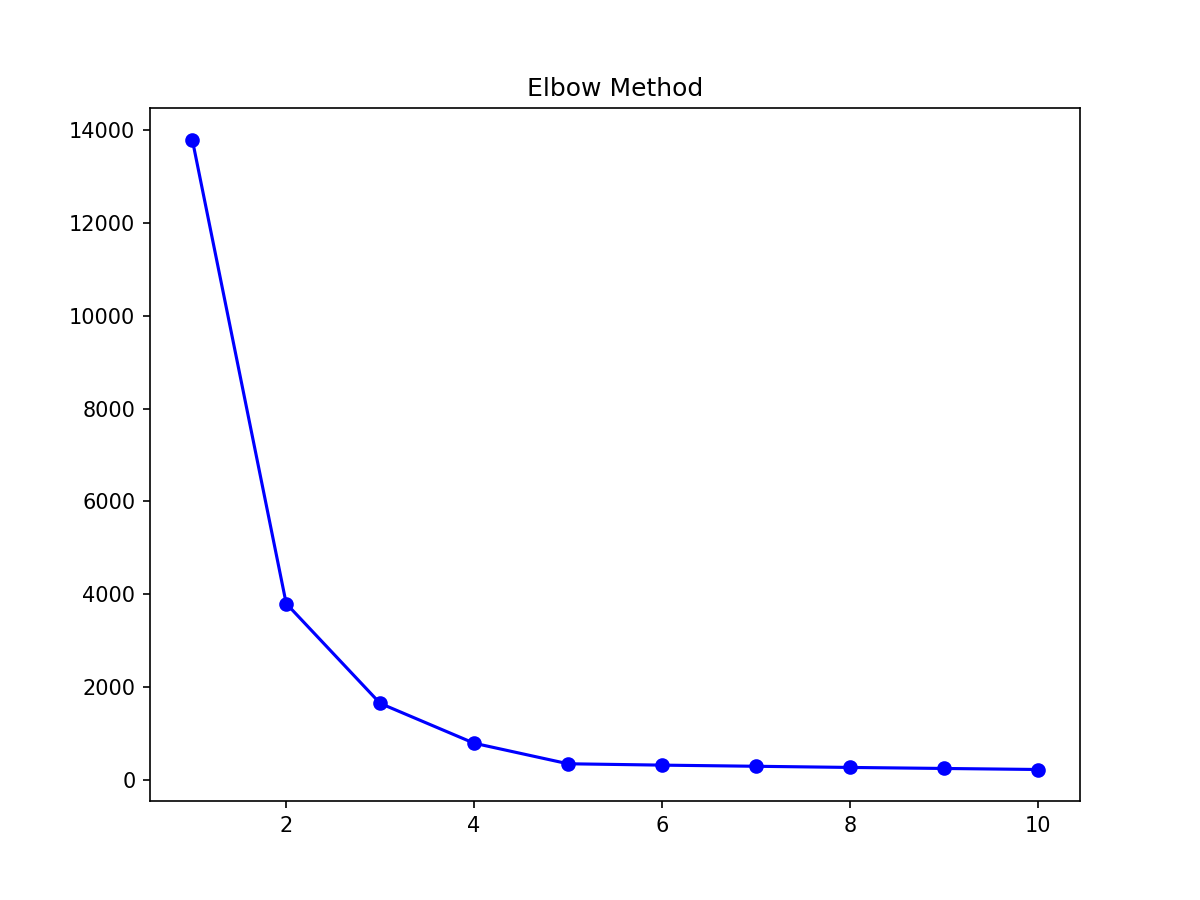

In [39]:
plt.figure(figsize=(8, 6))
plt.plot(k_range, inertia, 'bo-')
plt.title('Elbow Method')
plt.show()

після x = 5 наш 'y' майже не змінюється, отже k = 5.